In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("q2_customers.csv")

print("Shape:", df.shape)
df.head()

Shape: (500, 6)


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
X_scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


Scaling is essential before applying K-Means because the algorithm is distance-based (uses Euclidean distance).
If features are on different scales (e.g., age vs annual_spend), variables with larger values will dominate the clustering process.
StandardScaler ensures all features contribute equally by transforming them to have mean 0 and standard deviation 1

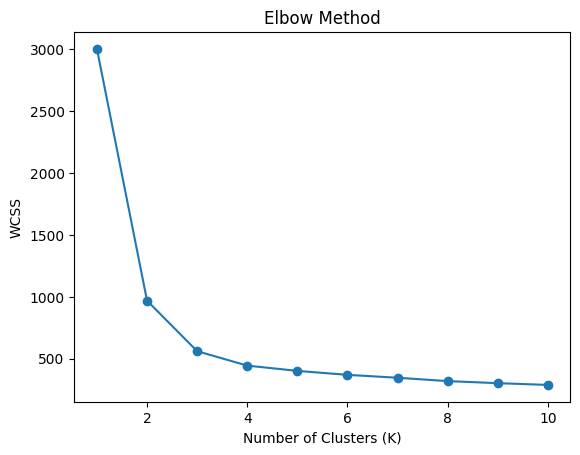

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

The elbow point appears around K = 3 or 4, where the rate of decrease in WCSS slows significantly.
This indicates that adding more clusters beyond this point does not significantly improve clustering performance.

In [6]:
# Fit KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column
df['cluster'] = clusters

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [7]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster 0
Represents customers with moderate spending, average visits, and balanced purchasing behavior.
Cluster 1
Represents high-value customers:
High annual spend
Frequent visits
Large basket size
 These are loyal and premium customers.
Cluster 2
Represents low-engagement customers:
Low spend
Fewer visits
Longer gap since last visit
 These customers may require re-engagement strategies.

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [9]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=["PC1", "PC2"]
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PC1 (Principal Component 1)
Captures overall customer value — strongly influenced by:
annual_spend
basket_size
visits_per_month

 Represents high vs low value customers

PC2 (Principal Component 2)
Captures recency and behavior patterns:
days_since_last_visit
category diversity

 Represents engagement vs inactivity

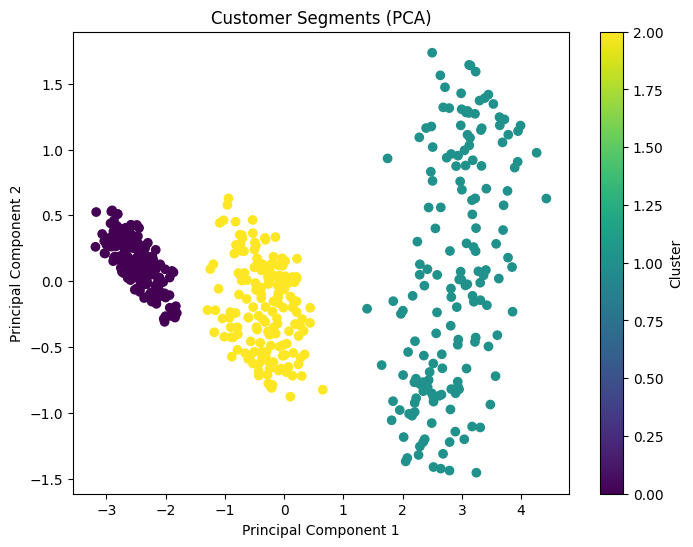

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
)

plt.title("Customer Segments (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")
plt.show()